## Comparativa de modelos

In [51]:
import joblib

# Carga de datasets
data = joblib.load('../data/processed_data.pkl')
print (f"Carga de datasets: { data.keys()} ")
X_test = data['X_test']
Y_test = data['y_test']

#Carga de modelos
models = [
    {"name": "KNN", "model": joblib.load('../models/knn_tuned.pkl') },
    {"name": "Decision Tree", "model": joblib.load('../models/decision_tree_tuned.pkl') },
    {"name": "Random Forest", "model": joblib.load('../models/random_forest_tuned.pkl') },
    {"name": "xgboost", "model": joblib.load('../models/xgboost_tuned.pkl') },
]

print(f"Carga de modelos: {len(models)}")

#Listar modelos
for model in models:
    print(f"\n** Model: {model['name']}**")
    print(f"Data keys: {model['model']}")
    




Carga de datasets: dict_keys(['X_train', 'X_test', 'y_train', 'y_test', 'feature_names']) 
Carga de modelos: 4

** Model: KNN**
Data keys: KNeighborsClassifier(n_jobs=-1, n_neighbors=4, weights='distance')

** Model: Decision Tree**
Data keys: DecisionTreeClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=36, min_samples_split=9,
                       random_state=42)

** Model: Random Forest**
Data keys: RandomForestClassifier(class_weight='balanced', max_depth=5, max_features=0.5,
                       min_samples_leaf=11, n_estimators=300, n_jobs=-1,
                       random_state=42)

** Model: xgboost**
Data keys: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.836965827544817, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='aucpr', feature_types=None, gamma=None,
       

In [52]:

#Predicciones
for model in models:
    y_prob = model['model'].predict_proba(X_test)
    print(f"Predictions for {model['name']}: {type(y_prob)}")
    print(f"{y_prob}")



Predictions for KNN: <class 'numpy.ndarray'>
[[1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 ...
 [1.         0.        ]
 [0.73863191 0.26136809]
 [1.         0.        ]]
Predictions for Decision Tree: <class 'numpy.ndarray'>
[[1.         0.        ]
 [1.         0.        ]
 [1.         0.        ]
 ...
 [0.53505535 0.46494465]
 [1.         0.        ]
 [1.         0.        ]]
Predictions for Random Forest: <class 'numpy.ndarray'>
[[0.70667786 0.29332214]
 [0.99699098 0.00300902]
 [0.98912502 0.01087498]
 ...
 [0.43444097 0.56555903]
 [0.39365487 0.60634513]
 [0.98750544 0.01249456]]
Predictions for xgboost: <class 'numpy.ndarray'>
[[0.7254007  0.2745993 ]
 [0.9502808  0.04971924]
 [0.93973935 0.06026063]
 ...
 [0.41295493 0.5870451 ]
 [0.42827523 0.5717248 ]
 [0.9332438  0.06675617]]


In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Comparativa de modelos
results = []

for model_dict in models:
    name = model_dict['name']
    model = model_dict['model']
    
    # Predicciones
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Métricas
    accuracy = accuracy_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred, average='binary')
    recall = recall_score(Y_test, y_pred, average='binary')
    f1 = f1_score(Y_test, y_pred, average='binary')
    auc = roc_auc_score(Y_test, y_prob) if y_prob is not None else None
    
    results.append({
        'Modelo': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc
    })

# Crear DataFrame con los resultados
df_results = pd.DataFrame(results)
print("Comparativa de Modelos:")
print(df_results)

Comparativa de Modelos:
          Modelo  Accuracy  Precision    Recall  F1-Score       AUC
0            KNN  0.932811   0.088235  0.040000  0.055046  0.594691
1  Decision Tree  0.762557   0.136020  0.720000  0.228814  0.795505
2  Random Forest  0.729941   0.122494  0.733333  0.209924  0.825633
3        xgboost  0.765819   0.137755  0.720000  0.231263  0.823420


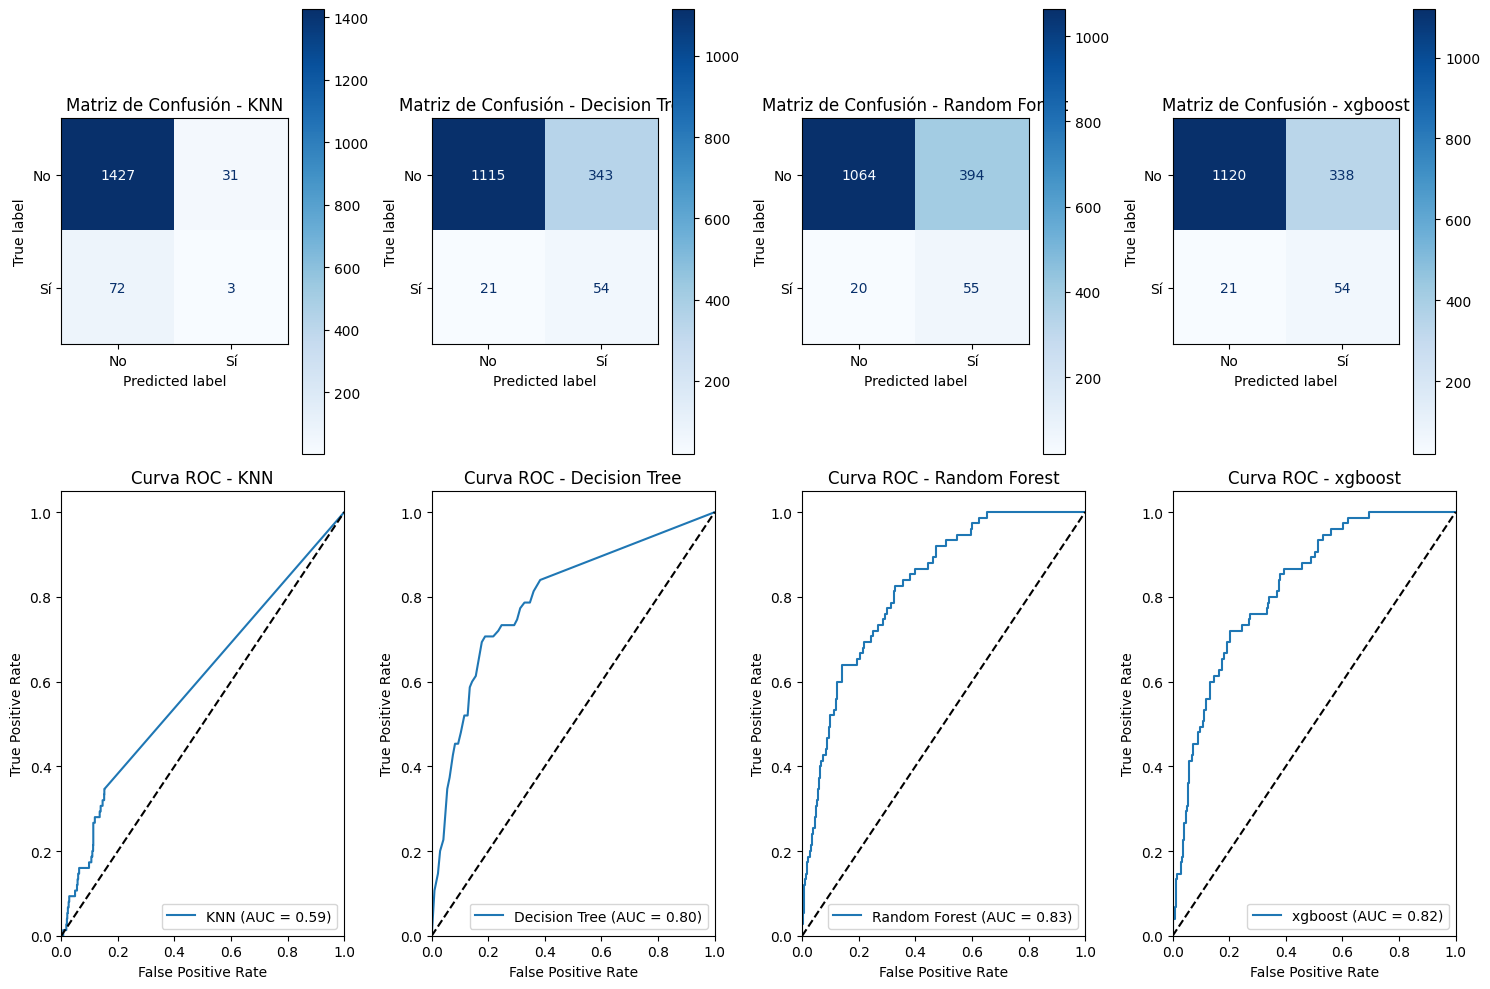

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Matrices de confusión y Curvas ROC
fig, axes = plt.subplots(2, len(models), figsize=(15, 10))
if len(models) == 1:
    axes = axes.reshape(2, -1)

plt.style.use('default')

for i, model_dict in enumerate(models):
    name = model_dict['name']
    model = model_dict['model']
    
    # Predicciones
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Matriz de confusión
    cm = confusion_matrix(Y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])  # Asumiendo clases binarias
    disp.plot(ax=axes[0, i], cmap=plt.cm.Blues)
    axes[0, i].set_title(f'Matriz de Confusión - {name}')
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1, i].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    axes[1, i].plot([0, 1], [0, 1], 'k--')
    axes[1, i].set_xlim([0.0, 1.0])
    axes[1, i].set_ylim([0.0, 1.05])
    axes[1, i].set_xlabel('False Positive Rate')
    axes[1, i].set_ylabel('True Positive Rate')
    axes[1, i].set_title(f'Curva ROC - {name}')
    axes[1, i].legend(loc="lower right")

plt.tight_layout()
plt.show()

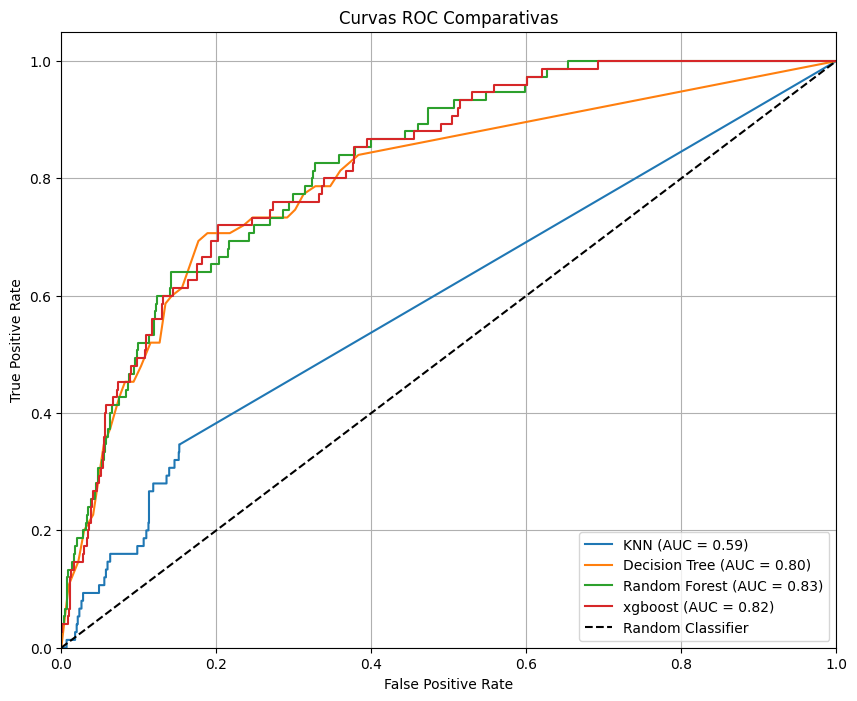

In [ ]:
# Curvas ROC superpuestas
plt.figure(figsize=(10, 8))

for model_dict in models:
    name = model_dict['name']
    model = model_dict['model']
    
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos positivos')
plt.ylabel('Tasa de Verdaderos positivos')
plt.title('Curvas ROC Comparativas')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()